<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/notebooks/janssen_snrna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Droplet-based single-nucleus RNA-seq with a genotype ground truth

The single-nucleus dataset analyzed elsewhere in the CellSweep manuscript (10x human kidney nuclei)
and the Parse 8-cubed experiments are both comparatively lowly contaminated. Droplet-based
single-nucleus RNA-seq is the regime where background RNA is most severe, because nuclei are
isolated by lysing cells and the resulting free RNA is carried into every droplet.

[Janssen et al. (2023), *Genome Biology* 24:140](https://doi.org/10.1186/s13059-023-02978-x)
generated exactly this kind of benchmark. Kidneys from three mouse strains -- one
*Mus musculus castaneus* (CAST/EiJ) and two *M. m. domesticus* (C57BL/6J and 129S1/SvImJ) -- were
pooled before droplet capture. Because the strains differ at ~32,000 homozygous SNPs, reads
carrying a foreign allele in a given nucleus are unambiguously background. Fitting a binomial
model to the cross-genotype allele counts gives a **per-cell ground-truth background fraction**
(`contPerCell_binom`, referred to as `bRNA` below) for every CAST nucleus.

Two of their five replicates are droplet-based snRNA-seq (`nuc2`, `nuc3`); the other three
(`rep1`--`rep3`) are scRNA-seq from the same animals. We use `nuc2` and `nuc3`.

This notebook

1. downloads the data and the companion code archive from Zenodo,
2. runs CellSweep on the raw CellRanger matrices using the authors' cell calls and cell-type
   labels,
3. **re-runs CellBender, DecontX (with and without empty droplets) and SoupX** at the settings
   the authors' benchmark marks as default, so every method sees identical inputs,
4. scores all five against the genotype ground truth with **the authors' own metric definitions**
   (Kendall's $\tau$ and RMSLE), and checks the re-runs against the values they publish
   (`Analysis/files/benchmark_metrics.RDS`), and
5. compares them gene by gene: dot plots over PT markers and broadly expressed genes, and, within
   non-PT nuclei, how much PT background each method removes against how much of those nuclei's
   own cell-type signal it removes.

Data: [10.5281/zenodo.7328632](https://doi.org/10.5281/zenodo.7328632) &nbsp;&nbsp;
Code: [10.5281/zenodo.7941521](https://doi.org/10.5281/zenodo.7941521)

Reading the `.RDS` files requires an R installation (`Rscript` on `PATH`); no R packages beyond
base R are needed. Re-running the other three methods needs a container runtime (`podman` or
`docker`); their outputs are cached, so the notebook can be re-run without them.

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import json
import shutil
import subprocess
import zipfile

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
from matplotlib.lines import Line2D
from scipy.stats import kendalltau

from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))

## Configuration

In [4]:
dataset_name = "janssen2023"
replicates = ["nuc2", "nuc3"]      # the two droplet-based snRNA-seq replicates
verbose = 1                         # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False                   # recompute outputs that already exist
threads = 16                        # numba threads for CellSweep

# Non-cellular barcodes are every barcode below `empty_umi_cutoff` that the authors did not call
# as a cell. We read the cutoff off the barcode-rank curve by eye: in both replicates the curve
# leaves its shoulder at a few hundred UMIs and lands in the empty-droplet tail below ~20; we
# put the cutoff on that cliff, at 100 UMIs in both replicates (see the knee plots).
empty_umi_cutoff = 100
empty_cutoff_sweep = [100, 500, 1000, "cellcount"]   # used by the sensitivity section

data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(data_dir, exist_ok=True)
os.makedirs(out_dir, exist_ok=True)

ZENODO_DATA = "https://zenodo.org/records/7328632/files"
ZENODO_CODE = ("https://zenodo.org/records/7941521/files/"
               "Hellmann-Lab/scRNA-seq_Contamination-first.zip")

# The 10 proximal-tubule markers Janssen et al. use for the marker-specificity metrics.
PT_MARKERS = ["Slc34a1", "Miox", "Pck1", "Slc4a4", "Ttc36", "Lrp2", "Fbp1", "Cyp2e1", "Fut9", "Khk"]

## Download

`nuc2.zip` (812 MB) and `nuc3.zip` (313 MB) each contain the raw and filtered CellRanger matrices,
the processed Seurat object (cell calls, SingleR cell types, strain assignments and the
genotype-based background estimate), and the per-cell genotype estimate on its own.

In [5]:
for rep in replicates:
    zip_path = os.path.join(data_dir, f"{rep}.zip")
    if not os.path.exists(os.path.join(data_dir, rep)):
        if not os.path.exists(zip_path):
            print(f"downloading {rep}.zip ...")
            !wget -q -c "{ZENODO_DATA}/{rep}.zip?download=1" -O {zip_path}
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(data_dir)
    print(rep, sorted(os.listdir(os.path.join(data_dir, rep))))

nuc2 ['adata_raw_empty100.h5ad', 'adata_raw_empty1000.h5ad', 'adata_raw_empty500.h5ad', 'adata_raw_emptycellcount.h5ad', 'filtered_feature_bc_matrix.h5', 'nuc2_output_cellsweep_empty100.h5ad', 'nuc2_output_cellsweep_empty1000.h5ad', 'nuc2_output_cellsweep_empty500.h5ad', 'nuc2_output_cellsweep_emptycellcount.h5ad', 'perCell_noMito_CAST_binom.RDS', 'raw_feature_bc_matrix.h5', 'seurat.RDS', 'seurat_CAST.RDS', 'seurat_cells.txt', 'seurat_genes.txt', 'seurat_metadata.csv', 'soup_profile.csv']
nuc3 ['adata_raw_empty100.h5ad', 'adata_raw_empty1000.h5ad', 'adata_raw_empty500.h5ad', 'adata_raw_emptycellcount.h5ad', 'filtered_feature_bc_matrix.h5', 'nuc3_output_cellsweep_empty100.h5ad', 'nuc3_output_cellsweep_empty1000.h5ad', 'nuc3_output_cellsweep_empty500.h5ad', 'nuc3_output_cellsweep_emptycellcount.h5ad', 'perCell_noMito_CAST_binom.RDS', 'raw_feature_bc_matrix.h5', 'seurat.RDS', 'seurat_CAST.RDS', 'seurat_cells.txt', 'seurat_genes.txt', 'seurat_metadata.csv', 'soup_profile.csv']


In [6]:
# The code archive carries the published benchmark numbers for CellBender, DecontX and SoupX.
code_zip = os.path.join(data_dir, "janssen_code.zip")
code_dir = os.path.join(data_dir, "janssen_code")
if not os.path.exists(code_dir):
    if not os.path.exists(code_zip):
        !wget -q -c "{ZENODO_CODE}?download=1" -O {code_zip}
    with zipfile.ZipFile(code_zip) as zf:
        zf.extractall(code_dir)
code_root = os.path.join(code_dir, os.listdir(code_dir)[0])
print(code_root)

/home/jrich/Desktop/cellsweep/notebooks/data/janssen2023/janssen_code/Hellmann-Lab-scRNA-seq_Contamination-4645c7a


## Read the R objects

The cell calls, cell-type labels, strain assignments and the genotype ground truth live in Seurat
`.RDS` files. We pull the metadata out with base R -- S4 slots are stored as attributes, so
`attr(x, "meta.data")` works without installing Seurat -- and write it to CSV.

In [7]:
R_EXPORT = r"""
suppressWarnings({
  args <- commandArgs(TRUE)               # one directory per replicate, then the shared data dir
  for (d in args[-length(args)]) {
    seu <- readRDS(file.path(d, "seurat.RDS"))
    md <- as.data.frame(attr(seu, "meta.data"))
    md$cell <- rownames(md)
    write.csv(md, file.path(d, "seurat_metadata.csv"), row.names = FALSE)
    cat(d, ": ", nrow(md), " cells, ", ncol(md), " metadata columns\n", sep = "")
    rm(seu); gc()
  }
  bm <- as.data.frame(readRDS(file.path(args[length(args)], "benchmark_metrics.RDS")))
  write.csv(bm, file.path(args[length(args)], "benchmark_metrics.csv"), row.names = FALSE)
})
"""

bench_src = os.path.join(code_root, "Analysis", "files", "benchmark_metrics.RDS")
shutil.copy(bench_src, os.path.join(data_dir, "benchmark_metrics.RDS"))

script = os.path.join(data_dir, "export_rds.R")
with open(script, "w") as f:
    f.write(R_EXPORT)

targets = [os.path.join(data_dir, rep) for rep in replicates] + [data_dir]
expected_csvs = ([os.path.join(data_dir, r, "seurat_metadata.csv") for r in replicates]
                 + [os.path.join(data_dir, "benchmark_metrics.csv")])
if overwrite or not all(os.path.exists(p) for p in expected_csvs):
    done = subprocess.run(["Rscript", script] + targets, capture_output=True, text=True)
    print(done.stdout or done.stderr)

In [8]:
metadata = {rep: pd.read_csv(os.path.join(data_dir, rep, "seurat_metadata.csv")).set_index("cell")
            for rep in replicates}
for rep, md_df in metadata.items():
    gt = md_df["bRNA"].dropna()
    print(f"{rep}: {len(md_df):,} cells  |  strains: {dict(md_df['Strain'].value_counts())}")
    print(f"      genotype ground truth for {len(gt):,} CAST nuclei, "
          f"median background {gt.median():.1%}, mean {gt.mean():.1%}, max {gt.max():.1%}")

nuc2: 16,714 cells  |  strains: {'SvImJ': np.int64(12707), 'BL6': np.int64(2493), 'CAST': np.int64(1514)}
      genotype ground truth for 1,514 CAST nuclei, median background 33.1%, mean 33.9%, max 77.6%
nuc3: 4,266 cells  |  strains: {'SvImJ': np.int64(3020), 'BL6': np.int64(848), 'CAST': np.int64(398)}
      genotype ground truth for 398 CAST nuclei, median background 18.0%, mean 20.4%, max 65.8%


The median nucleus in `nuc2` is one third background RNA, and in `nuc3` roughly one fifth. For
comparison, the human--mouse mixture analyzed in the main text sits near 1--3% contamination, and
the Parse 8-cubed plates lower still. This is the regime the method has to survive.

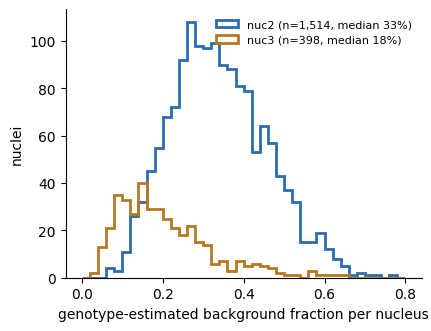

In [9]:
fig, ax = plt.subplots(figsize=(4.2, 3.2), constrained_layout=True)
for rep, color in zip(replicates, ["#2b6cb0", "#b7791f"]):
    gt = metadata[rep]["bRNA"].dropna()
    ax.hist(gt, bins=40, range=(0, 0.8), histtype="step", linewidth=2, color=color,
            label=f"{rep} (n={len(gt):,}, median {gt.median():.0%})")
ax.set_xlabel("genotype-estimated background fraction per nucleus")
ax.set_ylabel("nuclei")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.savefig(os.path.join(out_dir, "ground_truth_background.png"), dpi=300, bbox_inches="tight")
plt.show()

## Build the input matrices

CellSweep is run on the raw CellRanger matrix. We take the authors' called cells (so that the
evaluation is on exactly the barcodes their ground truth covers) together with their SingleR cell
type labels, and treat every remaining barcode below `empty_umi_cutoff` as non-cellular. Barcodes
that are neither -- above the cutoff but not called as cells -- are dropped, since they are
neither a labelled cell nor a trustworthy sample of the ambient pool.

In [10]:
def build_adata(rep, empty_umi_cutoff):
    """Raw CellRanger matrix restricted to called cells plus non-cellular barcodes."""
    md_df = metadata[rep]
    adata = cs_utils.load_adata(os.path.join(data_dir, rep, "raw_feature_bc_matrix.h5"), verbose=verbose)
    adata.var_names_make_unique()
    total = np.asarray(adata.X.sum(axis=1)).ravel()

    if empty_umi_cutoff == "cellcount":   # where the rest of this work places the cutoff:
        # the UMI count of the last barcode called as a cell.
        empty_umi_cutoff = int(np.sort(total)[::-1][len(md_df) - 1])

    is_cell = np.asarray(adata.obs_names.isin(md_df.index))
    keep = is_cell | ((total > 0) & (total < empty_umi_cutoff))
    adata = adata[keep].copy()

    adata.obs["total_counts"] = total[keep]
    adata.obs["is_empty"] = ~np.asarray(adata.obs_names.isin(md_df.index))
    adata.obs["celltype"] = pd.Series(md_df["celltype"]).reindex(adata.obs_names).fillna("empty").values
    for src, dst in [("Strain", "Strain"), ("bRNA", "bRNA"), ("nSNP", "nSNP"),
                     ("CI_low", "bRNA_CI_low"), ("CI_high", "bRNA_CI_high")]:
        adata.obs[dst] = pd.Series(md_df[src]).reindex(adata.obs_names).values
    adata.uns["empty_umi_cutoff"] = int(empty_umi_cutoff)

    n_cells, n_empty = int(is_cell.sum()), int((keep & ~is_cell).sum())
    print(f"{rep}: cutoff {empty_umi_cutoff:,} UMI  |  {n_cells:,} cells, {n_empty:,} non-cellular "
          f"barcodes, {int((~is_cell & (total >= empty_umi_cutoff)).sum()):,} barcodes dropped")
    return adata

In [11]:
adata_raw = {}
for rep in replicates:
    path = os.path.join(data_dir, rep, f"adata_raw_empty{empty_umi_cutoff}.h5ad")
    if os.path.exists(path) and not overwrite:
        adata_raw[rep] = ad.read_h5ad(path)
    else:
        adata_raw[rep] = build_adata(rep, empty_umi_cutoff)
        adata_raw[rep].write_h5ad(path)
adata_raw["nuc2"]

AnnData object with n_obs × n_vars = 1478720 × 28692
    obs: 'total_counts', 'is_empty', 'celltype', 'Strain', 'bRNA', 'nSNP', 'bRNA_CI_low', 'bRNA_CI_high'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'empty_umi_cutoff'

### Knee plots, and choosing the non-cellular cutoff

Both replicates show the shallow, poorly separated knee that is characteristic of high-background
droplet data: the called cells sit on a long shoulder with no clean gap beneath them. The
shoulder runs out at a few hundred UMIs and the curve then falls almost vertically into the
empty-droplet tail below ~20 UMIs. We put the non-cellular cutoff on that cliff, at 100 UMIs in
both replicates; the cell below prints the steepest point of each log-log curve, which lands at
74 UMIs in nuc2 and 61 in nuc3, so 100 sits just above it. The cutoff is a reading of the curve,
not a tuned parameter; the final section shows what happens if it is placed elsewhere.

In [12]:
def full_knee(rep):
    """Per-barcode totals over the whole raw matrix, read straight from the CellRanger h5.

    The AnnData we hand to CellSweep drops barcodes that are neither called cells nor below the
    noncellular cutoff, so its knee has an artificial cliff; the knee plot has to come from the
    unfiltered matrix."""
    import h5py
    cache = os.path.join(out_dir, f"{rep}_knee.npz")
    if os.path.exists(cache) and not overwrite:
        return np.load(cache)
    with h5py.File(os.path.join(data_dir, rep, "raw_feature_bc_matrix.h5")) as f:
        data, indptr = f["matrix/data"][:], f["matrix/indptr"][:]   # CSC: one column per barcode
    lengths = np.diff(indptr)
    totals = np.zeros(len(lengths), dtype=np.int64)
    nonempty = lengths > 0
    totals[nonempty] = np.add.reduceat(data.astype(np.int64), indptr[:-1][nonempty])
    counts = np.sort(totals[totals > 0])[::-1]
    np.savez_compressed(cache, counts=counts, n_cells=len(metadata[rep]))
    return np.load(cache)

nuc2: cliff inflection at rank 79,657 (74 UMI); cutoff at the called-cell count would be 1,285 UMI


nuc3: cliff inflection at rank 81,666 (61 UMI); cutoff at the called-cell count would be 2,722 UMI


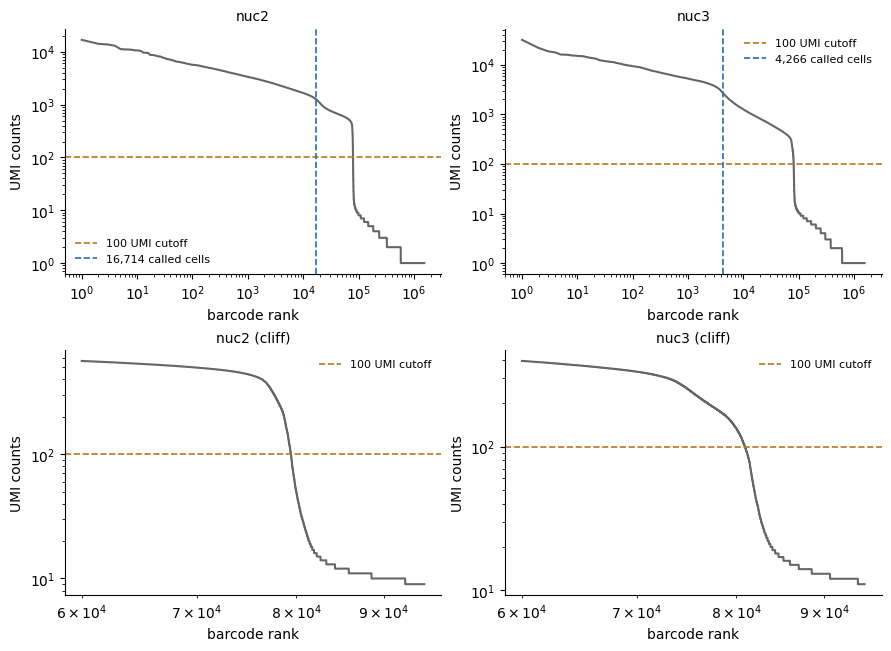

In [13]:
fig, axes = plt.subplots(2, len(replicates), figsize=(4.4 * len(replicates), 6.4), constrained_layout=True)
for col, rep in enumerate(replicates):
    knee = full_knee(rep)
    total, n_cells = knee["counts"], int(knee["n_cells"])
    rank = np.arange(1, len(total) + 1)
    # The inflection: steepest point of the smoothed log-log curve, searched below the cells.
    smooth = np.convolve(np.log10(total), np.ones(501) / 501, mode="same")
    slope = np.gradient(smooth, np.log10(rank))
    # Search between the shoulder and the empty-droplet tail; below ~10 UMIs the curve flattens
    # into long ties that produce their own spurious minima.
    lo, hi = np.searchsorted(-total, -1000), np.searchsorted(-total, -10)
    infl = lo + int(np.argmin(slope[lo:hi]))
    print(f"{rep}: cliff inflection at rank {infl + 1:,} ({total[infl]:,} UMI); cutoff at the "
          f"called-cell count would be {total[n_cells - 1]:,} UMI")
    for row, (lo_r, hi_r) in enumerate([(1, len(total)), (60_000, 95_000)]):
        ax = axes[row, col]
        m = (rank >= lo_r) & (rank <= hi_r)
        ax.plot(rank[m], total[m], color="0.4", linewidth=1.5)
        ax.axhline(empty_umi_cutoff, color="#b7791f", ls="--", linewidth=1.2,
                   label=f"{empty_umi_cutoff} UMI cutoff")
        if lo_r <= n_cells <= hi_r:
            ax.axvline(n_cells, color="#2b6cb0", ls="--", linewidth=1.2,
                       label=f"{n_cells:,} called cells")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("barcode rank"); ax.set_ylabel("UMI counts")
        ax.set_title(rep if row == 0 else f"{rep} (cliff)", fontsize=10)
        ax.legend(frameon=False, fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)
plt.savefig(os.path.join(out_dir, "knee_plots.png"), dpi=300, bbox_inches="tight")
plt.show()

## Run CellSweep

In [14]:
%%time
adata_cs = {}
for rep in replicates:
    path = os.path.join(data_dir, rep, f"{rep}_output_cellsweep_empty{empty_umi_cutoff}.h5ad")
    if not os.path.exists(path) or overwrite:
        denoise_count_matrix(
            adata_raw[rep].copy(),
            adata_out=path,
            freeze_ambient_profile=True,
            empty_droplet_method="threshold",
            umi_cutoff=int(adata_raw[rep].uns["empty_umi_cutoff"]),
            threads=threads,
            verbose=verbose,
            log_file=os.path.join(out_dir, f"{rep}_cellsweep_empty{empty_umi_cutoff}.log"),
        )
    adata_cs[rep] = ad.read_h5ad(path)
    adata_cs[rep] = adata_cs[rep][~adata_cs[rep].obs["is_empty"].values].copy()
    print(f"{rep}: beta_hat = {float(adata_cs[rep].uns['beta_hat']):.4f}")

nuc2: beta_hat = 0.0114


nuc3: beta_hat = 0.0003
CPU times: user 2.24 s, sys: 692 ms, total: 2.93 s
Wall time: 2.93 s


### Sanity checks

CellSweep should only ever subtract counts, should not collapse a large share of nuclei to zero,
and should leave per-gene totals monotonically related to the input.

In [15]:
# the raw counts for the same nuclei, as their own AnnData, for the comparison plots below
adata_in = {rep: ad.AnnData(adata_cs[rep].layers["raw"].copy(),
                            obs=adata_cs[rep].obs.copy(), var=adata_cs[rep].var.copy())
            for rep in replicates}

for rep in replicates:
    raw, den = adata_in[rep].X.tocsr(), adata_cs[rep].X.tocsr()
    alpha = adata_cs[rep].obs["alpha_hat"].values
    kept = np.asarray(den.sum(1)).ravel() / np.asarray(raw.sum(1)).ravel()
    print(f"{rep}:")
    print(f"  counts never increase                : {cs_utils.check_counts_less_equal(adata_in[rep], adata_cs[rep])}")
    print(f"  alpha_hat  median {np.median(alpha):.3f}   > 0.5: {(alpha > 0.5).mean():.1%}   > 0.9: {(alpha > 0.9).mean():.1%}")
    print(f"  signal retained per nucleus  median {np.median(kept):.1%}   min {kept.min():.1%}")
    print(f"  nuclei emptied entirely (0 counts left): {(np.asarray(den.sum(1)).ravel() == 0).sum():,}")

nuc2:


  counts never increase                : True
  alpha_hat  median 0.276   > 0.5: 6.9%   > 0.9: 0.0%
  signal retained per nucleus  median 71.6%   min 0.0%
  nuclei emptied entirely (0 counts left): 0
nuc3:


  counts never increase                : True
  alpha_hat  median 0.126   > 0.5: 5.7%   > 0.9: 2.1%
  signal retained per nucleus  median 87.3%   min 0.0%
  nuclei emptied entirely (0 counts left): 0


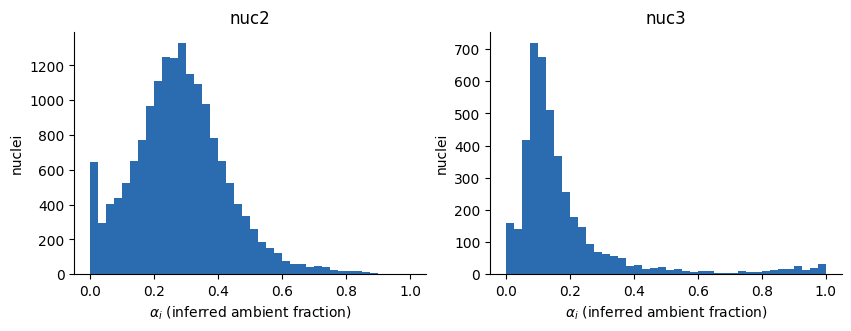

In [16]:
fig, axes = plt.subplots(1, len(replicates), figsize=(4.2 * len(replicates), 3.2), constrained_layout=True)
for ax, rep in zip(np.atleast_1d(axes), replicates):
    ax.hist(adata_cs[rep].obs["alpha_hat"], bins=40, color="#2b6cb0")
    ax.set_xlabel(r"$\alpha_i$ (inferred ambient fraction)"); ax.set_ylabel("nuclei"); ax.set_title(rep)
    ax.spines[["top", "right"]].set_visible(False)
plt.savefig(os.path.join(out_dir, "alpha_hat_histograms.png"), dpi=300, bbox_inches="tight")
plt.show()

Extracting all nonzero pairs from sparse matrices...


Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


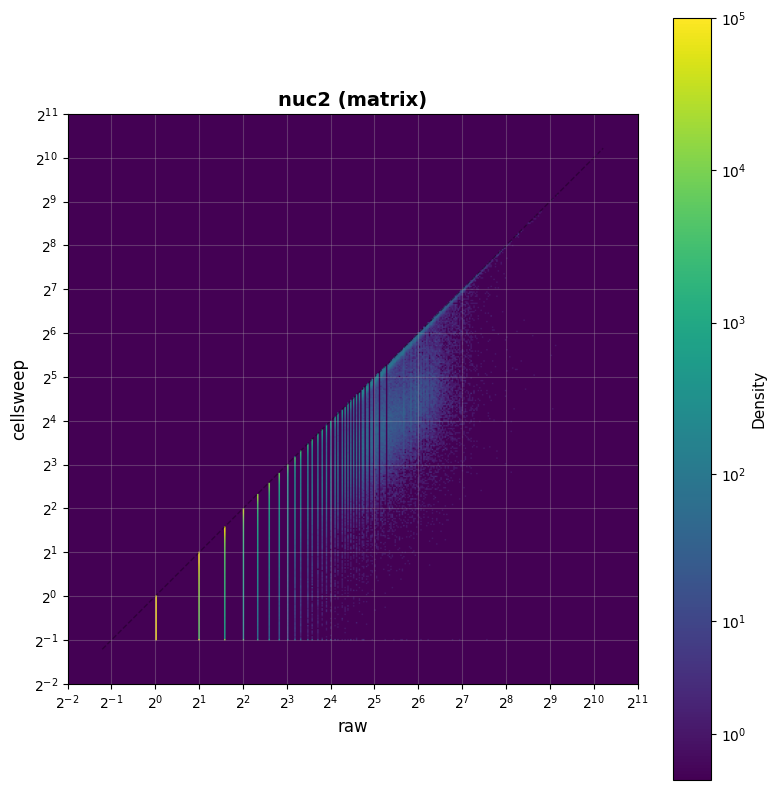

Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


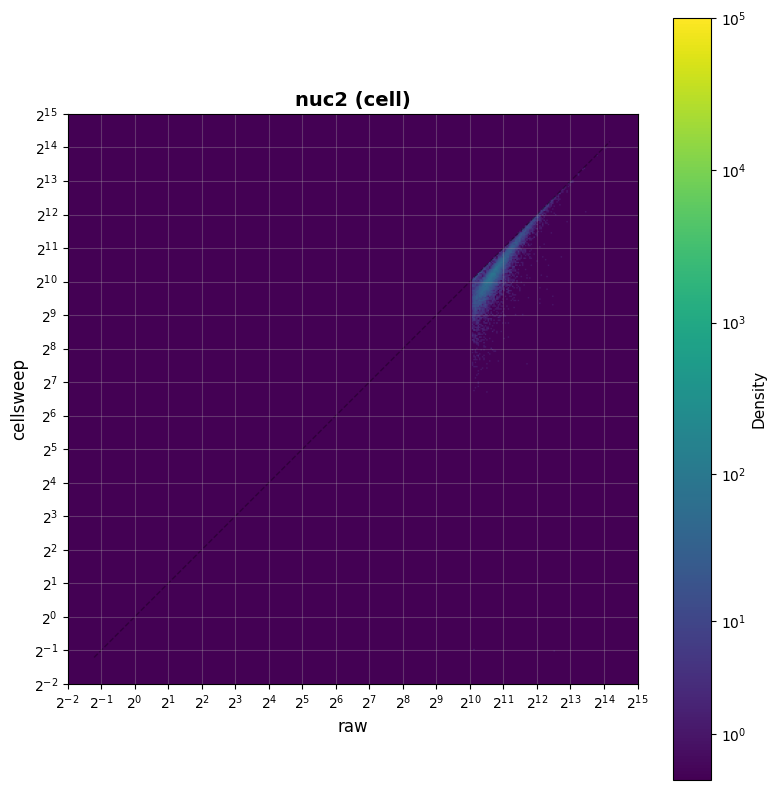

Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


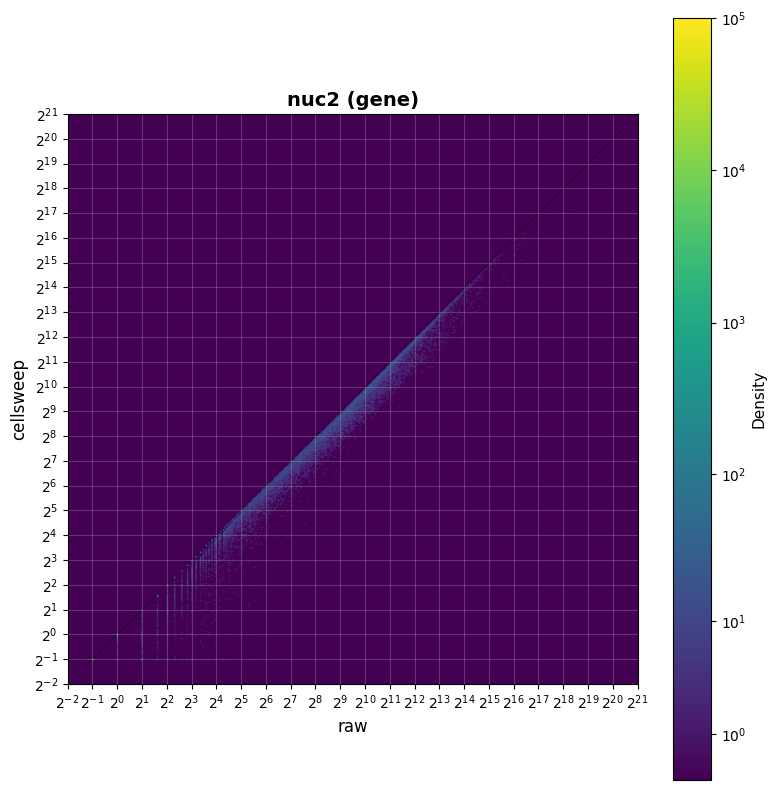

Extracting all nonzero pairs from sparse matrices...


Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


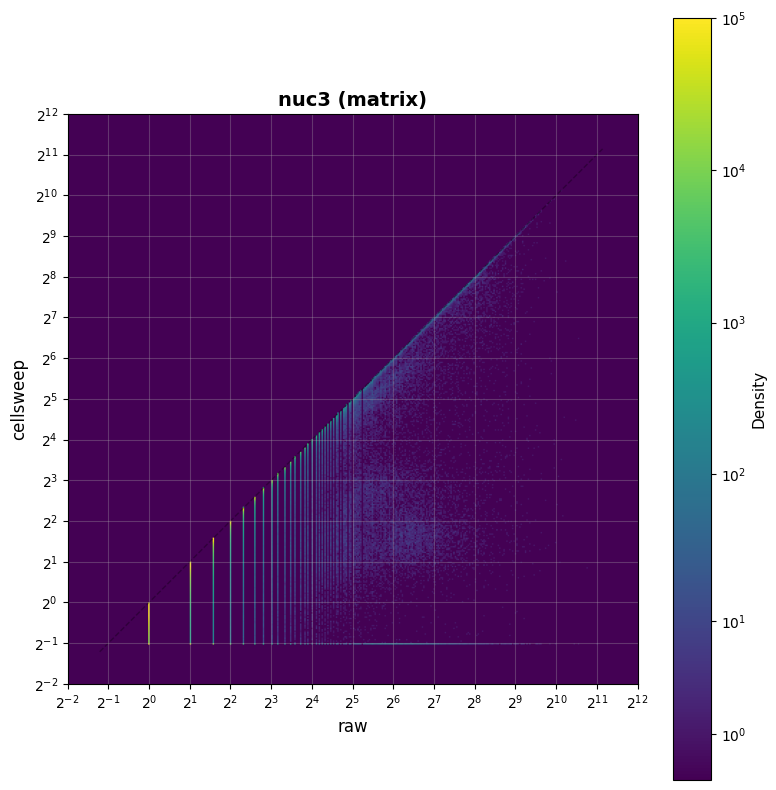

Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


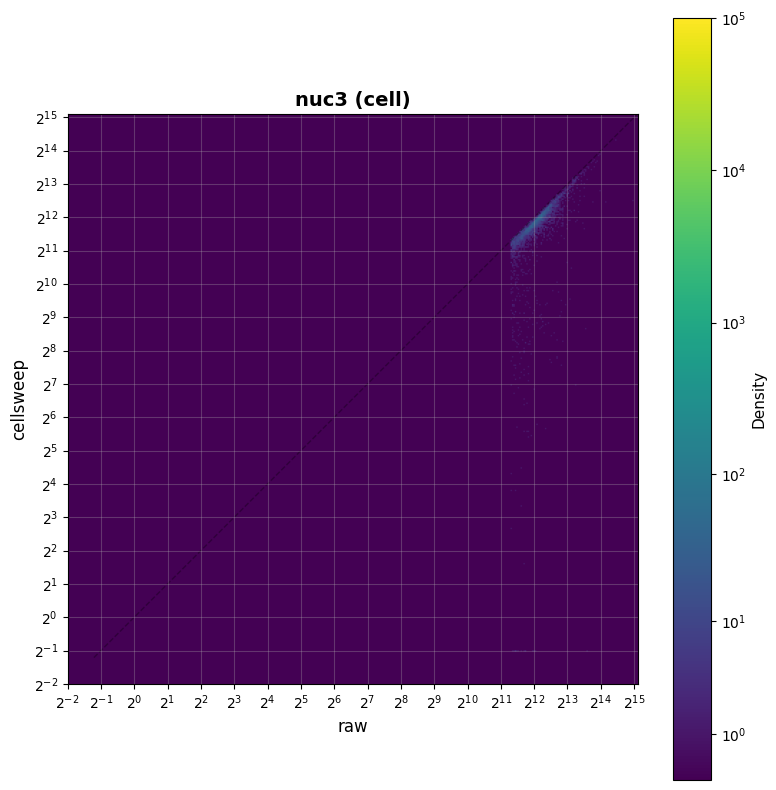

Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


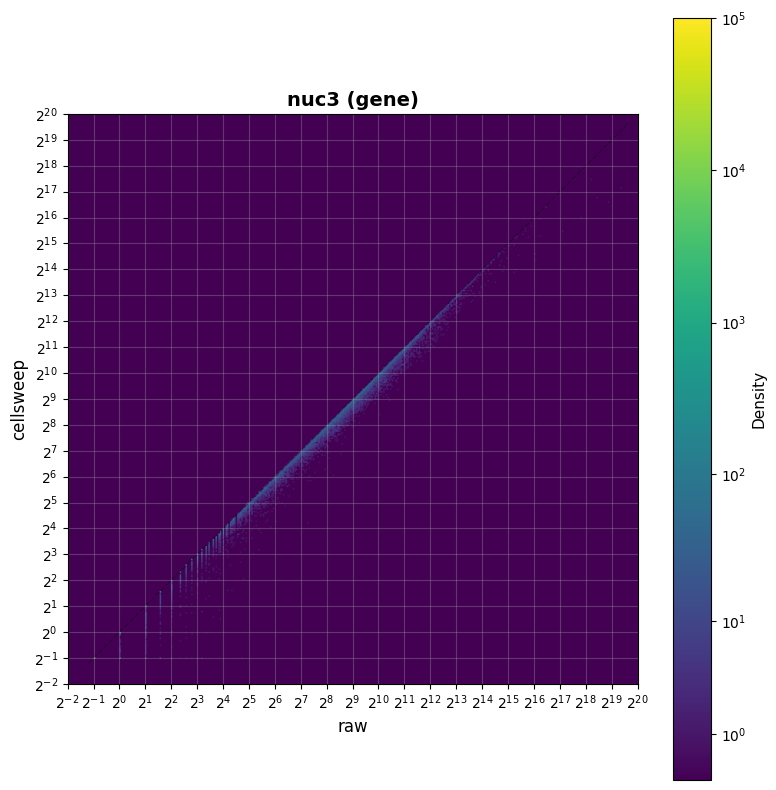

In [17]:
for rep in replicates:
    for point_type in ["matrix", "cell", "gene"]:
        cs_utils.plot_matrix_scatterplot(
            adata_in[rep], adata_cs[rep], point_type=point_type,
            density_type="scatter_with_density", scale="log",
            x_axis="raw", y_axis="cellsweep", title=f"{rep} ({point_type})",
            out_path=os.path.join(out_dir, f"{rep}_scatter_{point_type}.png"))

## Running the other correction methods

To compare methods on the same footing we re-run CellBender, DecontX and SoupX ourselves, at the
parameter settings Janssen et al. flag as `default = TRUE` in their `benchmark_metrics.RDS`:

| method | setting |
|---|---|
| CellBender | `--expected-cells <n cells> --total-droplets-included 25000 --fpr 0.01 --epochs 150` |
| DecontX | `decontX(x, z = NULL, background = NULL)` -- its own clustering, no empty droplets |
| DecontX (empty) | `decontX(x, z = NULL, background = raw)` -- ambient profile from empty droplets |
| SoupX | `autoEstCont()` on the authors' `RNA_snn_res.1` clusters, soup from droplets with 0-100 UMIs |

`scripts/run_janssen_tools.R` mirrors their `run_DecontX.R` / `run_SoupX.R` on the CellRanger h5
directly, so that the only thing that differs from their pipeline is the machine it ran on. All
of it runs in containers; on a machine without a GPU CellBender takes several hours per replicate.

In [18]:
import sys

container = "podman"     # or "docker"
run_tools = False        # set True to re-run the containers (hours for CellBender)

tool_dir = os.path.join(out_dir, "tools")
os.makedirs(tool_dir, exist_ok=True)
data_root = os.path.realpath(os.path.join(cellsweep_dir, "notebooks", "data"))
scripts_dir = os.path.join(cellsweep_dir, "scripts")

r_image = "docker.io/josephrich98/cellsweep_tutorials:decontx.0.1.0"
cb_image = "us.gcr.io/broad-dsde-methods/cellbender:0.3.0"
# podman under SELinux needs label=disable to run these images; harmless elsewhere.
mount = ["--security-opt", "label=disable"]

sys.path.insert(0, scripts_dir)
import janssen_loaders as jl

for rep in replicates:
    # SoupX's soup profile, precomputed so R never has to subset the 6.8M-barcode raw matrix.
    if run_tools or not os.path.exists(os.path.join(data_dir, rep, "soup_profile.csv")):
        jl.write_soup_profile(rep)

    for tool in ["decontx", "decontx_empty", "soupx"]:
        if not run_tools and os.path.exists(os.path.join(tool_dir, f"{rep}_{tool}.mtx")):
            continue
        subprocess.run([container, "run", "--rm", *mount,
                        "-v", f"{scripts_dir}:/work/scripts",
                        "-v", f"{out_dir}:/work/out",
                        "-v", f"{os.path.join(data_root, dataset_name)}:/work/data",
                        r_image, "Rscript", "/work/scripts/run_janssen_tools.R", tool,
                        f"/work/data/{rep}", f"/work/out/tools/{rep}_{tool}"], check=True)

    cb_out = os.path.join(tool_dir, f"cb_{rep}")
    if run_tools or not os.path.exists(os.path.join(cb_out, f"{rep}_cellbender.h5")):
        os.makedirs(cb_out, exist_ok=True)
        subprocess.run([container, "run", "--rm", *mount,
                        "-v", f"{os.path.join(data_root, dataset_name)}:/data",
                        "-v", f"{tool_dir}:/out", "-w", f"/out/cb_{rep}", cb_image,
                        "cellbender", "remove-background",
                        "--input", f"/data/{rep}/raw_feature_bc_matrix.h5",
                        "--output", f"/out/cb_{rep}/{rep}_cellbender.h5",
                        "--expected-cells", str(len(metadata[rep])),
                        "--total-droplets-included", "25000", "--fpr", "0.01",
                        "--epochs", "150", "--cpu-threads", str(threads)], check=True)

## Marker panels

Two kinds of gene go into the comparison.

* **PT markers** -- the ten proximal-tubule genes Janssen et al. use
  (`Snakemake_benchmark/input/top10_PT_markers.RDS`). PT is ~85% of the nuclei here, so the
  ambient pool is essentially PT RNA; every PT-marker count in a non-PT nucleus is background.
* **Broadly expressed genes** -- genes at a similar level in every nucleus type. They are in the
  ambient pool too, so some of their counts *should* come off; what would be wrong is stripping
  them out of the nuclei that genuinely express them.

For the quantitative summary we also need, for each non-PT type, the genes that type actually
expresses. `celltype_markers()` ranks genes by their expression in a type relative to PT. Because
the contamination flows out of PT, this can only under-rank a real marker, never invent one -- and
the panels it returns are textbook (`Slc12a1`/`Umod` for aLOH, `Slc12a3` for DCT, `Aqp2` for
CD_PC, `Nphs2`/`Podxl` for podocytes, `Flt1`/`Emcn` for endothelium).

In [19]:
import analyze_janssen_markers as jm
import make_janssen_figure as jf

print("PT markers:        ", ", ".join(jl.PT_MARKERS))
print("broadly expressed: ", ", ".join(jl.CONSTITUTIVE))

PT markers:         Slc34a1, Miox, Pck1, Slc4a4, Ttc36, Lrp2, Fbp1, Cyp2e1, Fut9, Khk
broadly expressed:  Malat1, Fth1, Ftl1, Tpt1, Psap, App


In [20]:
%%time
# Writes dotplot_<rep>.csv and removal_<rep>.csv for every method whose output is on disk.
jm.run(out_dir=out_dir)

cell-type marker panels:
  Endo     Meis2, Adgrl4, Plpp1, Flt1, Ldb2, Emcn, Samd12, Ptprb
  aLOH     Erbb4, Slc12a1, Mecom, Egf, Slit2, Rgs6, Abca13, Umod
  dLOH     Spp1, Psca, Ly6d, Upk3a, Upk1b, Alcam, Slc12a2, Rbms3
  DCT      Slc8a1, Slc12a3, Abca13, Trpm6, Mecom, Calb1, Phactr1, Wnk1
  CD_IC    Tmem117, Slc26a4, Pde4b, Slc4a9, Thsd7a, Nbea, Bmpr1b, Mecom
  CNT      Slc8a1, Egfem1, Phactr1, Frmpd4, Mecom, Nr3c2, Slit2, Calb1
  MC       Cfh, Igfbp3, Prkg1, Ren1, Fbln5, Pde3a, Igfbp5, Ctgf
  Podo     Podxl, Magi2, Nphs2, Srgap1, Thsd7a, Robo2, Ptpro, Pard3b
  CD_PC    Aqp2, Frmpd4, Phactr1, Mecom, Mgat4c, Cacnb2, Bmpr1b, Nr3c2
  [nuc2] raw: kept 1.000 of counts


  [nuc2] CellSweep: kept 0.773 of counts


  [nuc2] CellBender: kept 0.527 of counts


  [nuc2] DecontX: kept 0.805 of counts


  [nuc2] DecontX (empty): kept 0.642 of counts


...

  [nuc3] CellSweep: kept 0.889 of counts


  [nuc3] CellBender: kept 0.927 of counts


  [nuc3] DecontX: kept 0.835 of counts


  [nuc3] DecontX (empty): kept 0.842 of counts


  [nuc3] SoupX: kept 0.757 of counts
         method   n   tau  rmsle  median_estimate  median_ground_truth
      CellSweep 398 0.105  0.193            0.077                 0.18
     CellBender 398 0.237  0.136            0.074                 0.18
        DecontX 398 0.133  0.156            0.052                 0.18
DecontX (empty) 398 0.234  0.156            0.102                 0.18
          SoupX 398 0.034  0.106            0.238                 0.18
done
CPU times: user 55.2 s, sys: 7.13 s, total: 1min 2s
Wall time: 49.1 s


## Estimation accuracy against the genotype ground truth

Janssen et al. score a method by the fraction of counts it removes from each nucleus,
$\mathrm{cont}_i = 1 - \sum_g \widehat{C}_{ig} / \sum_g C_{ig}$, and compare that to the
genotype estimate with Kendall's $\tau$ and
$\mathrm{RMSLE} = \sqrt{\mathrm{mean}\left[(\log(1+\mathrm{gt}) - \log(1+\mathrm{est}))^2\right]}$
(`Snakemake_benchmark/scripts/evaluate_estimation_accuracy.R`). Their Seurat objects exclude the
13 mitochondrial genes, and the ground truth is likewise computed off mitochondrial reads, so we
drop those genes before summing.

In [21]:
def per_cell_contamination(adata):
    """1 - (denoised counts / raw counts) per nucleus, over non-mitochondrial genes."""
    keep_gene = ~adata.var_names.str.startswith("mt-")
    raw = np.asarray(adata.layers["raw"].tocsr()[:, keep_gene].sum(axis=1)).ravel()
    den = np.asarray(adata.X.tocsr()[:, keep_gene].sum(axis=1)).ravel()
    return 1 - den / np.maximum(raw, 1)


def estimation_accuracy(ground_truth, estimate):
    ok = ~np.isnan(ground_truth)
    gt, est = ground_truth[ok], estimate[ok]
    return dict(n=int(ok.sum()),
                tau=float(kendalltau(gt, est).statistic),
                rmsle=float(np.sqrt(np.mean((np.log1p(gt) - np.log1p(est)) ** 2))))

In [22]:
accuracy = {rep: pd.read_csv(os.path.join(out_dir, f"accuracy_{rep}.csv")) for rep in replicates}
for rep, df in accuracy.items():
    print(f"=== {rep} ===")
    print(df.round(3).to_string(index=False))

percell = {}
for rep in replicates:
    est = per_cell_contamination(adata_cs[rep])
    percell[rep] = pd.DataFrame({
        "bRNA": adata_cs[rep].obs["bRNA"].values,
        "nSNP": adata_cs[rep].obs["nSNP"].values,
        "est": est,
        "alpha_hat": adata_cs[rep].obs["alpha_hat"].values,
        "celltype": adata_cs[rep].obs["celltype"].values,
        "Strain": adata_cs[rep].obs["Strain"].values,
        "total_counts": np.asarray(adata_cs[rep].layers["raw"].sum(axis=1)).ravel(),
    }, index=adata_cs[rep].obs_names)
    percell[rep].to_csv(os.path.join(out_dir, f"{rep}_percell.csv"))
    g = percell[rep].dropna(subset=["bRNA"])
    print(f"{rep}: median ground truth {g['bRNA'].median():.1%} vs "
          f"median CellSweep estimate {g['est'].median():.1%}")

=== nuc2 ===
         method    n   tau  rmsle  median_estimate  median_ground_truth
      CellSweep 1514 0.322  0.113            0.259                0.331
     CellBender 1514 0.218  0.212            0.558                0.331
        DecontX 1514 0.153  0.164            0.163                0.331
DecontX (empty) 1514 0.332  0.090            0.332                0.331
          SoupX 1514 0.169  0.116            0.438                0.331
=== nuc3 ===
         method   n   tau  rmsle  median_estimate  median_ground_truth
      CellSweep 398 0.105  0.193            0.077                 0.18
     CellBender 398 0.237  0.136            0.074                 0.18
        DecontX 398 0.133  0.156            0.052                 0.18
DecontX (empty) 398 0.234  0.156            0.102                 0.18
          SoupX 398 0.034  0.106            0.238                 0.18


nuc2: median ground truth 33.1% vs median CellSweep estimate 25.9%
nuc3: median ground truth 18.0% vs median CellSweep estimate 7.7%


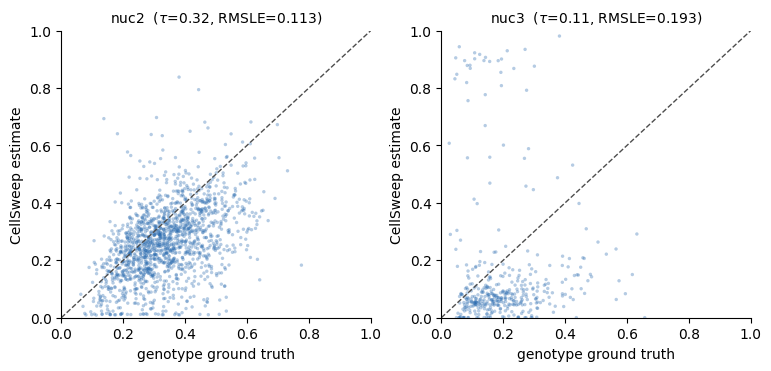

In [23]:
fig, axes = plt.subplots(1, len(replicates), figsize=(3.8 * len(replicates), 3.6), constrained_layout=True)
for ax, rep in zip(np.atleast_1d(axes), replicates):
    g = percell[rep].dropna(subset=["bRNA"])
    ax.scatter(g["bRNA"], g["est"], s=6, alpha=0.35, color="#2b6cb0", edgecolors="none")
    ax.plot([0, 1], [0, 1], color="0.3", ls="--", linewidth=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("genotype ground truth"); ax.set_ylabel("CellSweep estimate")
    a = accuracy[rep].set_index("method").loc["CellSweep"]
    ax.set_title(f"{rep}  ($\\tau$={a['tau']:.2f}, RMSLE={a['rmsle']:.3f})", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
plt.savefig(os.path.join(out_dir, "estimate_vs_ground_truth.png"), dpi=300, bbox_inches="tight")
plt.show()

### Against the published benchmark

`Analysis/files/benchmark_metrics.RDS` holds the values Janssen et al. report for CellBender,
DecontX and SoupX on these same nuclei. We ran every method ourselves, so this is a check on the
re-runs rather than the comparison itself: the two columns should agree up to the stochastic
parts of each method (DecontX clusters its own cells; CellBender is a stochastic fit).

In [24]:
bench = pd.read_csv(os.path.join(data_dir, "benchmark_metrics.csv"))
published = (bench.query("evaluation_category == 'estimation_accuracy' and default")
                  .query("replicate in @replicates")
                  .assign(method=lambda d: np.where(d["param"].str.contains("emptyTrue"),
                                                    d["method"] + " (empty)", d["method"]))
                  .pivot_table(index=["replicate", "method"], columns="metric", values="value")
                  .add_suffix("_published"))
ours = pd.concat({rep: df.set_index("method") for rep, df in accuracy.items()},
                 names=["replicate", "method"])[["tau", "rmsle"]].add_suffix("_ours")
ours.join(published, how="outer").sort_index().round(3)

tau_ours  rmsle_ours  rmsle_published  \
replicate method                                                   
nuc2      CellBender          0.218       0.212            0.113   
          CellSweep           0.322       0.113              NaN   
          DecontX             0.153       0.164            0.162   
          DecontX (empty)     0.332       0.090            0.091   
          SoupX               0.169       0.116            0.116   
nuc3      CellBender          0.237       0.136            0.168   
          CellSweep           0.105       0.193              NaN   
          DecontX             0.133       0.156            0.156   
          DecontX (empty)     0.234       0.156            0.128   
          SoupX               0.034       0.106            0.106   

                           tau_published  
replicate method                          
nuc2      CellBender               0.322  
          CellSweep                  NaN  
          DecontX                  0.174  
          DecontX (empty)          0.347  
          SoupX                    0.169  
nuc3      CellBender               0.101  
          CellSweep                  NaN  
          DecontX                  0.131  
          DecontX (empty)          0.214  
          SoupX                    0.034

## Dot plots

The clearest picture of what each method does is a dot plot of the same nuclei before and after
correction: dot size is the fraction of nuclei with a (rounded) non-zero count, colour is mean
expression relative to the cell type where that gene peaks. Expression is normalised by each
nucleus's *uncorrected* library size, so a method cannot look better simply by having removed
counts from the denominator.

In the uncorrected panel every PT marker is detected in essentially every nucleus type at close
to its PT level -- the signature of massive background. A method that works turns the PT-marker
block into a single dark row for PT and near-empty rows beneath it, while leaving the
broadly-expressed block alone.

wrote /home/jrich/Desktop/cellsweep/notebooks/output/janssen2023/janssen_dotplots.png


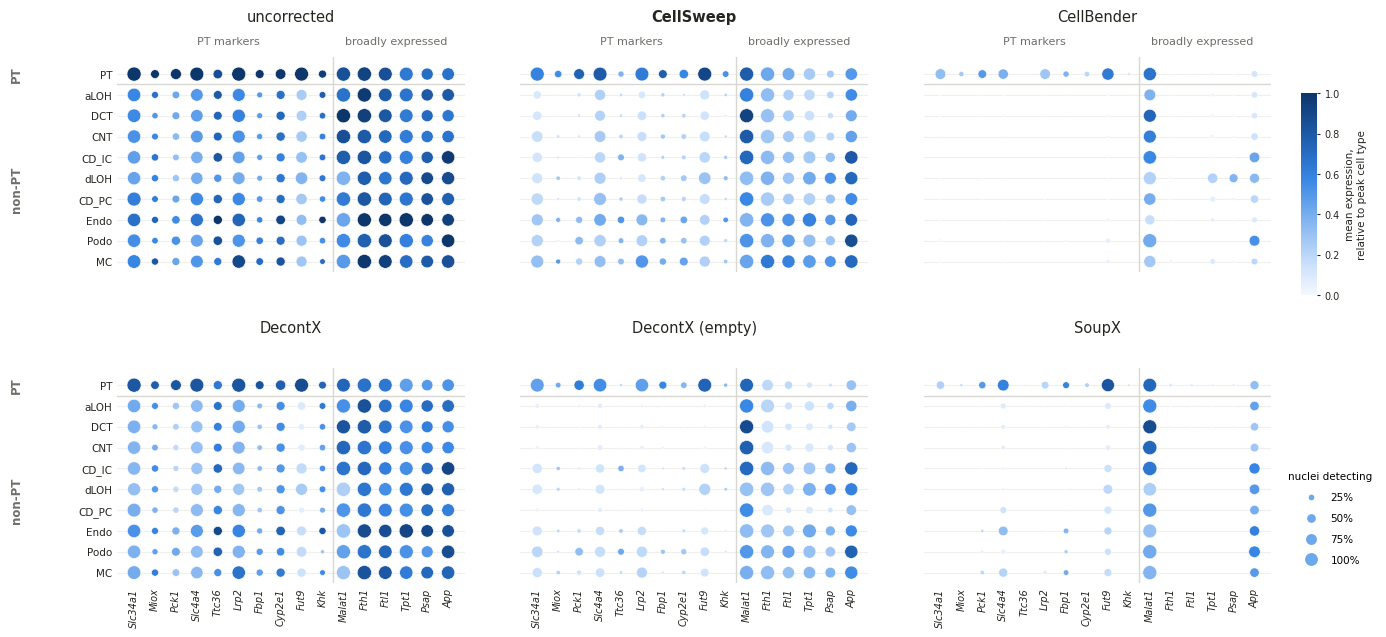

In [25]:
dot = pd.read_csv(os.path.join(out_dir, "dotplot_nuc2.csv"))
jf.build_dotplots(dot, "nuc2", os.path.join(out_dir, "janssen_dotplots.png"))

## How much background, and how much signal

The dot plots summarise to two numbers, both computed **within non-PT nuclei only**:

* the fraction of **PT-marker counts** removed -- these are background, so the ideal is 1;
* the fraction of **own-cell-type marker counts** removed -- these are signal, so the ideal is 0.

Each is the mean over all non-PT nuclei of that nucleus's own fraction removed.

=== nuc2 ===
gene_set         PT noise  own-type signal
method                                    
CellBender          0.990            0.255
CellSweep           0.612            0.044
DecontX             0.305            0.026
DecontX (empty)     0.831            0.075
SoupX               0.933            0.070
=== nuc3 ===
gene_set         PT noise  own-type signal
method                                    
CellBender          0.968            0.005
CellSweep           0.526            0.120
DecontX             0.270            0.006
DecontX (empty)     0.715            0.183
SoupX               0.971            0.035


wrote /home/jrich/Desktop/cellsweep/notebooks/output/janssen2023/janssen_removal.png


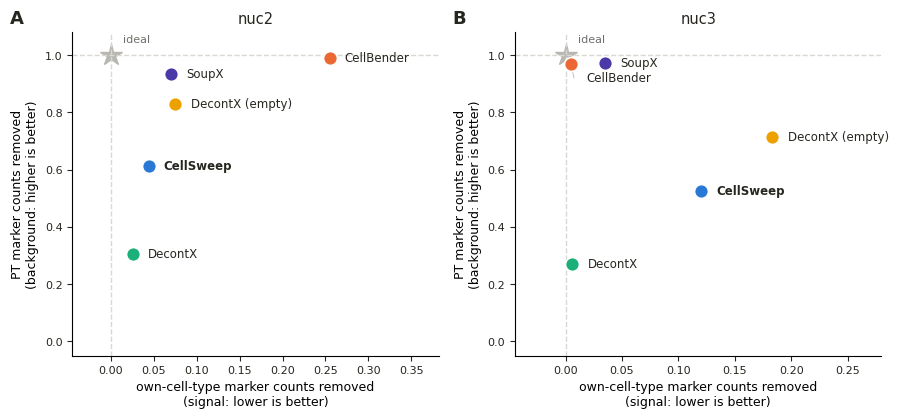

In [26]:
removal = {rep: pd.read_csv(os.path.join(out_dir, f"removal_{rep}.csv")) for rep in replicates}
for rep, df in removal.items():
    print(f"=== {rep} ===")
    print(jm.summarise(df).round(3).to_string())
jf.build_removal(removal, os.path.join(out_dir, "janssen_removal.png"))

### The other half of the question: what comes off the signal

The comparison above only looks at non-PT nuclei, where every PT-marker count is background. A
method can score perfectly there by deleting those genes everywhere, PT nuclei included, which is
not decontamination. The dot plots show whether that has happened; these two numbers measure it.
A nucleus here is ~33% (nuc2) or ~18% (nuc3) background and the background is PT RNA, so a
calibrated method should remove roughly that fraction of a PT nucleus's own PT-marker counts, and
roughly that fraction of the broadly expressed genes across all nuclei. Substantially more than
that is over-correction.

In [27]:
retention = {rep: pd.read_csv(os.path.join(out_dir, f"retention_{rep}.csv")) for rep in replicates}
for rep, df in retention.items():
    print(f"=== {rep} (ground-truth median background "
          f"{accuracy[rep]['median_ground_truth'].iloc[0]:.1%}) ===")
    print(df.pivot(index="method", columns="gene_set",
                   values="frac_removed_mean").round(3).to_string())

=== nuc2 (ground-truth median background 33.1%) ===
gene_set         PT markers in PT nuclei  broadly expressed, all nuclei
method                                                                 
CellBender                         0.631                          0.522
CellSweep                          0.291                          0.254
DecontX                            0.176                          0.186
DecontX (empty)                    0.462                          0.371
SoupX                              0.610                          0.440
=== nuc3 (ground-truth median background 18.0%) ===
gene_set         PT markers in PT nuclei  broadly expressed, all nuclei
method                                                                 
CellBender                         0.158                          0.147
CellSweep                          0.126                          0.127
DecontX                            0.157                          0.141
DecontX (empty)                 

## Sensitivity to the non-cellular barcode cutoff

The cutoff above was read off the barcode-rank curve. This section checks what it costs to get it
wrong, by re-running CellSweep with the cutoff at 500 and 1,000 UMIs -- inside the shoulder -- and
at the UMI count of the last called cell, which is where the rest of the manuscript places it.
Both replicates degrade as near-cell barcodes are pulled into the ambient profile: the ambient
profile picks up real cellular signal, `alpha_hat` saturates for more nuclei, and the correlation
with the genotype ground truth falls away. This is the one parameter the method is genuinely
sensitive to on data this contaminated.

In [28]:
%%time
sweep_rows = []
for rep in replicates:
    for cutoff in empty_cutoff_sweep:
        tag = f"empty{cutoff}"
        raw_path = os.path.join(data_dir, rep, f"adata_raw_{tag}.h5ad")
        out_path = os.path.join(data_dir, rep, f"{rep}_output_cellsweep_{tag}.h5ad")
        if not os.path.exists(out_path) or overwrite:
            a = ad.read_h5ad(raw_path) if os.path.exists(raw_path) else build_adata(rep, cutoff)
            if not os.path.exists(raw_path):
                a.write_h5ad(raw_path)
            denoise_count_matrix(a, adata_out=out_path, freeze_ambient_profile=True,
                                 empty_droplet_method="threshold",
                                 umi_cutoff=int(a.uns["empty_umi_cutoff"]), threads=threads,
                                 verbose=0, log_file=os.path.join(out_dir, f"{rep}_cellsweep_{tag}.log"))
        a = ad.read_h5ad(out_path)
        a = a[~a.obs["is_empty"].values].copy()
        est = per_cell_contamination(a)
        row = dict(replicate=rep, cutoff=cutoff, umi=int(a.uns["empty_umi_cutoff"]),
                   frac_alpha_above_0p9=float((a.obs["alpha_hat"].values > 0.9).mean()),
                   median_estimate=float(np.median(est)),
                   **estimation_accuracy(a.obs["bRNA"].values.astype(float), est))
        sweep_rows.append(row)
sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(os.path.join(out_dir, "empty_cutoff_sweep.csv"), index=False)
sweep_df.round(3)

CPU times: user 11.2 s, sys: 3 s, total: 14.2 s
Wall time: 14.2 s


,replicate,cutoff,umi,frac_alpha_above_0p9,median_estimate,n,tau,rmsle
0,nuc2,100,100,0.000,0.242,1514,0.322,0.113
1,nuc2,500,500,0.012,0.328,1514,0.258,0.100
2,nuc2,1000,1000,0.019,0.334,1514,0.263,0.101
3,nuc2,cellcount,1285,0.017,0.332,1514,0.270,0.100
4,nuc3,100,100,0.021,0.071,398,0.105,0.193
5,nuc3,500,500,0.037,0.104,398,0.057,0.215
6,nuc3,1000,1000,0.054,0.116,398,-0.003,0.279
7,nuc3,cellcount,2722,0.105,0.101,398,0.012,0.318
